In [1]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
import glob, os, sys

from data.movie import Frames, Audio #, People Measures
from data.spikes import Rates # LFP, BOLD
from data.behavior import Gaze, Suspense # Suspense, Valence, Arousal

from tqdm import tqdm


### helpers

In [2]:
rescale_t = 1

min_max = lambda x: (x - x.min()) / (x.max() - x.min())

def get_region_mtx(df_FRs, region):

    region_cols = [col for col in df_FRs.columns if region in col]
    region_mtx = df_FRs[region_cols].copy().values

    return region_mtx # t by N

### suspense & FRs

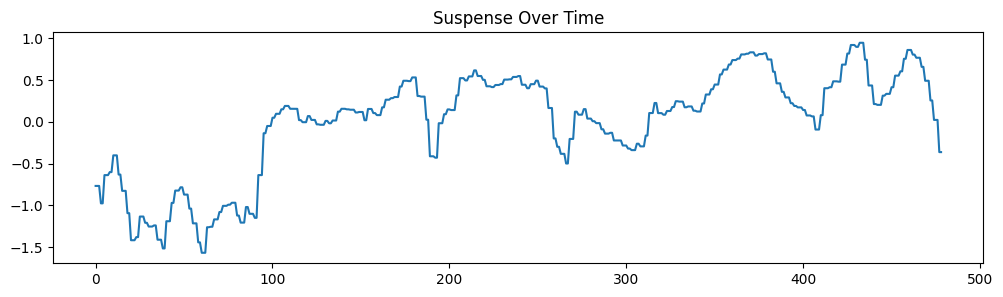

In [3]:
suspense = Suspense().rescale(rescale_t)
avg_suspense = suspense.mean(axis=1)

plt.figure(figsize=(12, 3))
plt.title('Suspense Over Time')
plt.plot(avg_suspense)
plt.show()

### audio

In [30]:
audio = Audio()
audio_metrics = [
    audio.vocals.arousal,
    audio.vocals.dominance,
    audio.vocals.valence,
    audio.vocals.angry,
    audio.vocals.sad,
    audio.vocals.happy,
    audio.vocals.surprise,
    audio.vocals.neutral,
]

# apply rescaling and stack into a matrix
rescaled_metrics = [data.rescale(1) for data in audio_metrics]
aud_mtx = np.stack(rescaled_metrics, axis=1)  # shape: (n_timepoints, n_features)

# # build DataFrame with names
# colnames = [
#     'arousal', 'dominance', 'valence', 'angry',
#     'sad', 'happy', 'surprise', 'neutral',
# ]
# df_audio = pd.DataFrame(X, columns=colnames)

In [21]:
# # plot
# corr = df_audio.corr()
# plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
# plt.colorbar(label='Correlation')
# plt.xticks(range(len(corr)), corr.columns, rotation=90)
# plt.yticks(range(len(corr)), corr.columns)
# plt.title('Correlation Matrix (Rescaled)')
# plt.tight_layout()
# plt.show()


### visual

In [ ]:
# load visual metrics (e.g., pix diff, number of faces, etc.)
# rescale to 1, such that i have vis_mtx which has shape = (N, T)

100%|██████████| 144/144 [00:00<00:00, 182.44it/s]


### forming conds

In [7]:
cond_names = {
    0: 'Low Sensory, Low Suspense',
    1: 'Low Sensory, High Suspense',
    2: 'High Sensory, Low Suspense',
    3: 'High Sensory, High Suspense'
}

def get_conds(df_audio, avg_suspense, sen_thresh=50, sus_thresh=50):
    
    """
    Determine conditions based on audio features and suspense levels.
    Args:
        df_audio (pd.DataFrame): DataFrame containing audio features.
        avg_suspense (np.ndarray): Array of average suspense values.
    Returns:
        sen_sus_conds (np.ndarray): Array of conditions based on sensory and suspense levels.
    """

    # Sensory conditions based on audio features
    sensory_output = df_audio.prod(axis=1)  # shape: (n_timepoints,)
    sensory_cond = np.array((sensory_output > np.percentile(sensory_output, sen_thresh)))
    suspense_cond = np.array((avg_suspense > np.percentile(avg_suspense, sus_thresh)))

    sen_sus_conds = sensory_cond * 2 + suspense_cond # resulting in 0,1,2,3

    return sen_sus_conds


In [31]:
# setup
sen_sus_conds = get_conds(aud_mtx, avg_suspense)

# checking
unique, counts = np.unique(sen_sus_conds, return_counts=True)
cond_counts = dict(zip(unique, counts))
for cond in range(4):
    print(f'{cond_names[cond]} pts: {cond_counts[cond]}')


Low Sensory, Low Suspense pts: 139
Low Sensory, High Suspense pts: 101
High Sensory, Low Suspense pts: 102
High Sensory, High Suspense pts: 137


### FRs

In [32]:
df_FRs = Rates().rescale(rescale_t)
T_by_N = df_FRs.values
N_by_T = T_by_N.T
regions = ['ACC', 'amygdala', 'hippocampus', 'vmPFC', 'preSMA']
df_FRs

,Left_ACC_P58CS_R1_1_1_994_6,Right_ACC_P58CS_R1_35_2_2425_5,Right_ACC_P58CS_R1_35_1_2195_5,Right_ACC_P58CS_R1_34_4_3301_5,Right_ACC_P58CS_R1_34_3_3299_5,Right_ACC_P58CS_R1_34_2_3239_5,Right_ACC_P58CS_R1_34_1_3232_5,Right_ACC_P58CS_R1_36_1_712_5,Right_ACC_P58CS_R1_36_2_962_5,Right_ACC_P58CS_R1_38_1_1473_5,...,Right_amygdala_P62CS_R1_28_1_6059_3,Right_amygdala_P62CS_R1_27_3_8498_3,Right_preSMA_P62CS_R1_22_3_2598_7,Right_preSMA_P62CS_R1_22_2_2532_7,Right_preSMA_P62CS_R1_22_1_2407_7,Right_preSMA_P62CS_R1_18_3_3847_7,Right_preSMA_P62CS_R1_18_2_3846_7,Right_preSMA_P62CS_R1_18_1_3830_7,Right_vmPFC_P62CS_R1_7_1_791_9,Right_vmPFC_P62CS_R1_5_1_1374_9
0.0,-1.180952,-0.666667,-0.038095,-7.571838,0.573146,-0.180843,-0.476190,0.795238,0.476495,0.766888,...,-0.095238,0.0,-0.790561,-1.066667,-0.095238,0.094940,6.925359,-1.447619,-0.777148,-0.146550
1.0,-1.180952,-0.666667,-0.038095,-8.202274,-1.276910,0.696879,-0.476190,1.023172,2.044693,3.017722,...,-0.095238,0.0,-0.630207,-1.066518,-0.095238,0.197187,1.132730,-1.447619,-0.008835,-0.693488
2.0,-1.180952,-0.666667,-0.038095,-1.101670,-0.291149,1.215248,-0.476042,2.343321,1.756937,0.573081,...,-0.095238,0.0,2.944444,-0.732895,-0.095238,-0.828569,4.641910,-1.447619,-0.382118,-0.698561
3.0,-1.180952,-0.666667,-0.038095,16.731459,0.516851,0.797838,0.357031,0.713225,1.656819,2.021726,...,-0.095238,0.0,-1.361343,-0.483885,-0.095238,0.374791,2.576883,-1.447619,0.048688,-0.520191
4.0,-1.180952,-0.666667,-0.038095,4.201117,-1.605757,-0.936392,0.629848,0.032041,0.411422,0.199649,...,-0.095238,0.0,-1.493237,-1.066369,-0.095238,-0.624775,1.638817,-1.447619,0.205105,0.772155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
474.0,-1.180952,-0.666444,-0.038095,0.259806,-0.260076,0.245400,0.106591,-0.038095,-0.405524,-0.899779,...,-0.095238,0.0,1.178466,-0.812422,-0.095238,-0.522212,4.394781,0.020986,0.388416,0.104934
475.0,-1.180952,0.065940,0.026968,-2.397802,-0.296222,0.587232,-0.142419,-0.038095,0.346359,0.028604,...,-0.095238,0.0,1.556020,-0.294400,-0.095238,-1.002982,-2.216291,0.639553,0.390149,1.657467
476.0,-1.180952,1.858703,1.007953,-0.770127,-1.277058,0.503567,-0.470969,-0.038095,1.118477,-0.887318,...,-0.095238,0.0,-1.661036,-0.334060,-0.090165,1.441956,-0.000958,-0.649801,0.599016,0.542973
477.0,-1.180952,-0.027478,0.791433,5.790031,-0.260187,1.712850,0.554981,0.010702,0.424004,-0.952381,...,-0.095238,0.0,0.374543,0.296958,0.685493,-0.887434,-1.216143,0.166446,0.048688,1.269342


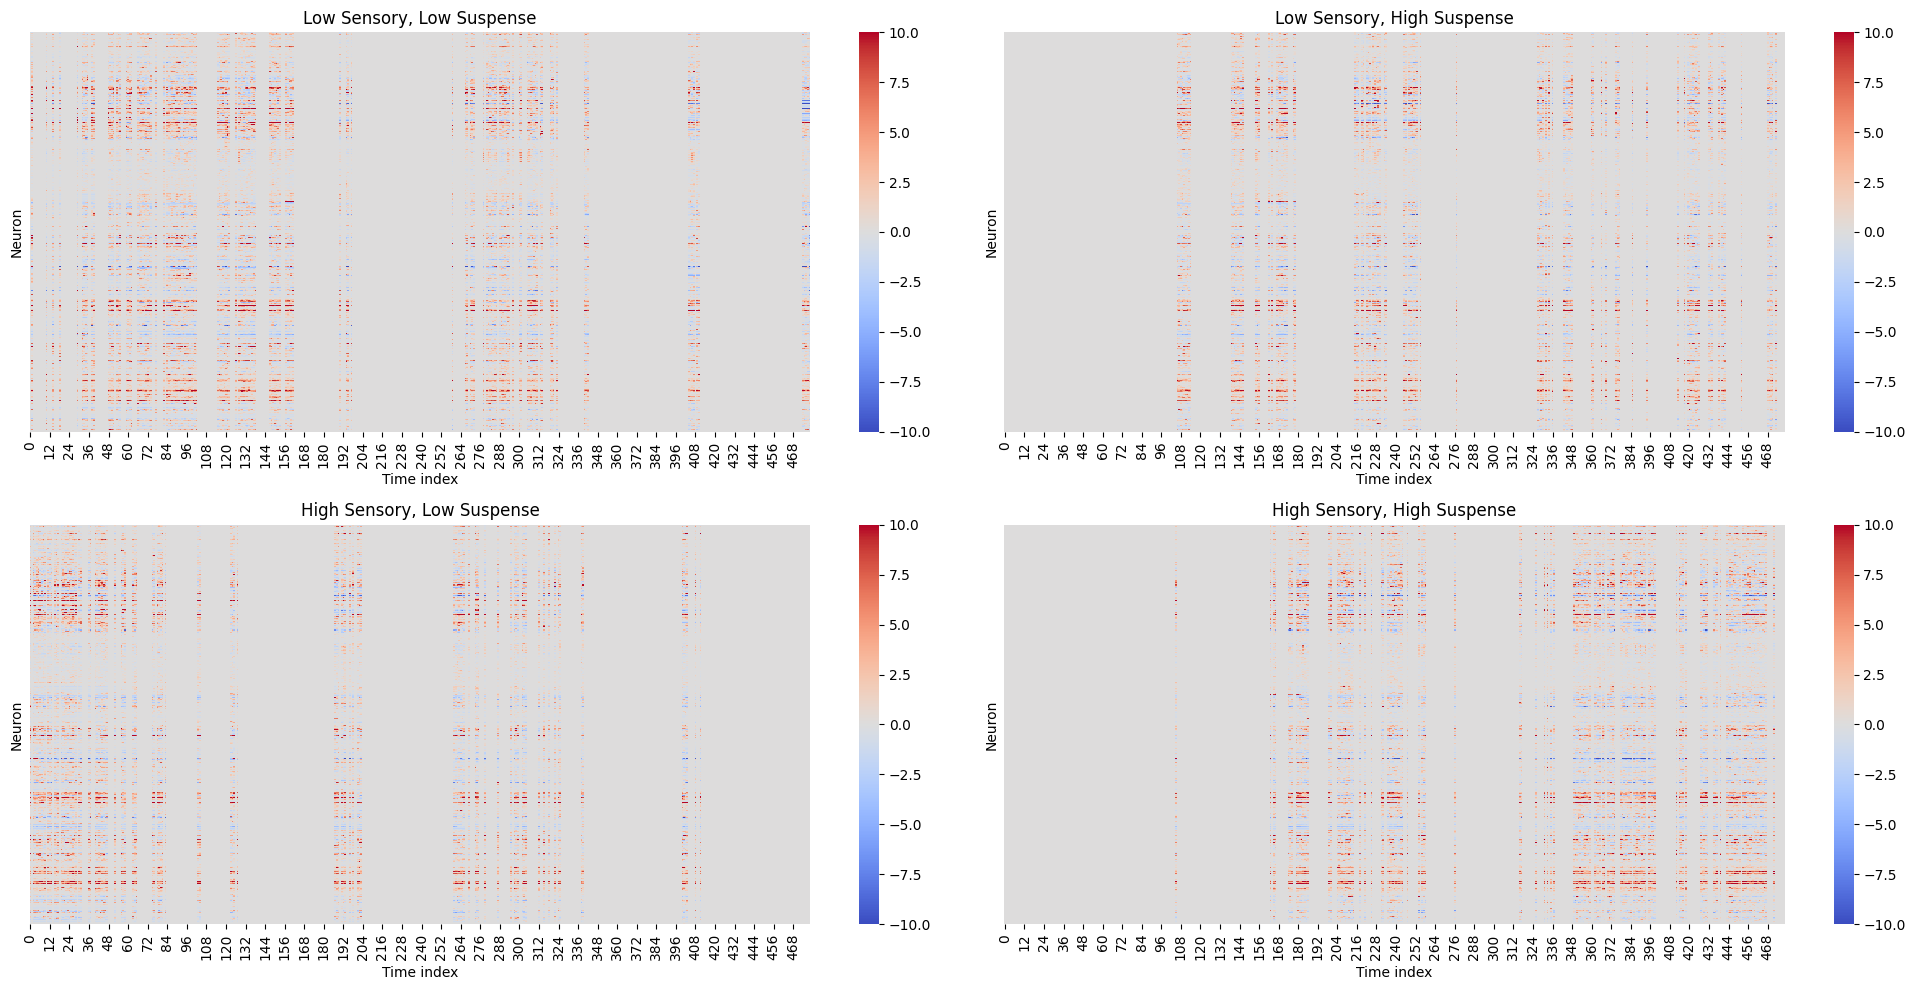

In [33]:
# plot
region = 'amygdala'

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
axs, ax = axs.flatten(), 0
FR_plt_rng = 10

for cond in range(4):
    
    if region == '': cond_N_by_T = N_by_T.copy() # full mtx
    else:            cond_N_by_T = get_region_mtx(df_FRs, region).copy().T # region mtx

    # nullify non-condition times
    cond_N_by_T[:, sen_sus_conds != cond] = 0
    
    assert cond_N_by_T.shape[1] == len(suspense), "mtx improperly transposed"

    sns.heatmap(cond_N_by_T, cmap='coolwarm', ax=axs[ax], vmin=-FR_plt_rng, vmax=FR_plt_rng)
    axs[ax].set(title=f'{cond_names[cond]}', xlabel='Time index', ylabel='Neuron', yticks=[])
    ax += 1

plt.tight_layout()
plt.show()

### GLMs

In [34]:
# setup
from sklearn.linear_model import Ridge

T_by_feats = df_audio.values
print(T_by_N.shape)
assert T_by_N.shape[0] == T_by_feats.shape[0], "Timepoints do not match between FRs and audio features"


(479, 1457)


In [35]:
# function
def get_GLM(X, Y):

    model = Ridge(alpha=1.0)
    coefs = []
    for n in range(Y.shape[1]):
        model.fit(X, Y[:, n])
        coefs.append(model.coef_)  # shape: (n_features,)

    coefs = np.array(coefs).T  # shape: (n_feats, n_neurs)
    
    return coefs

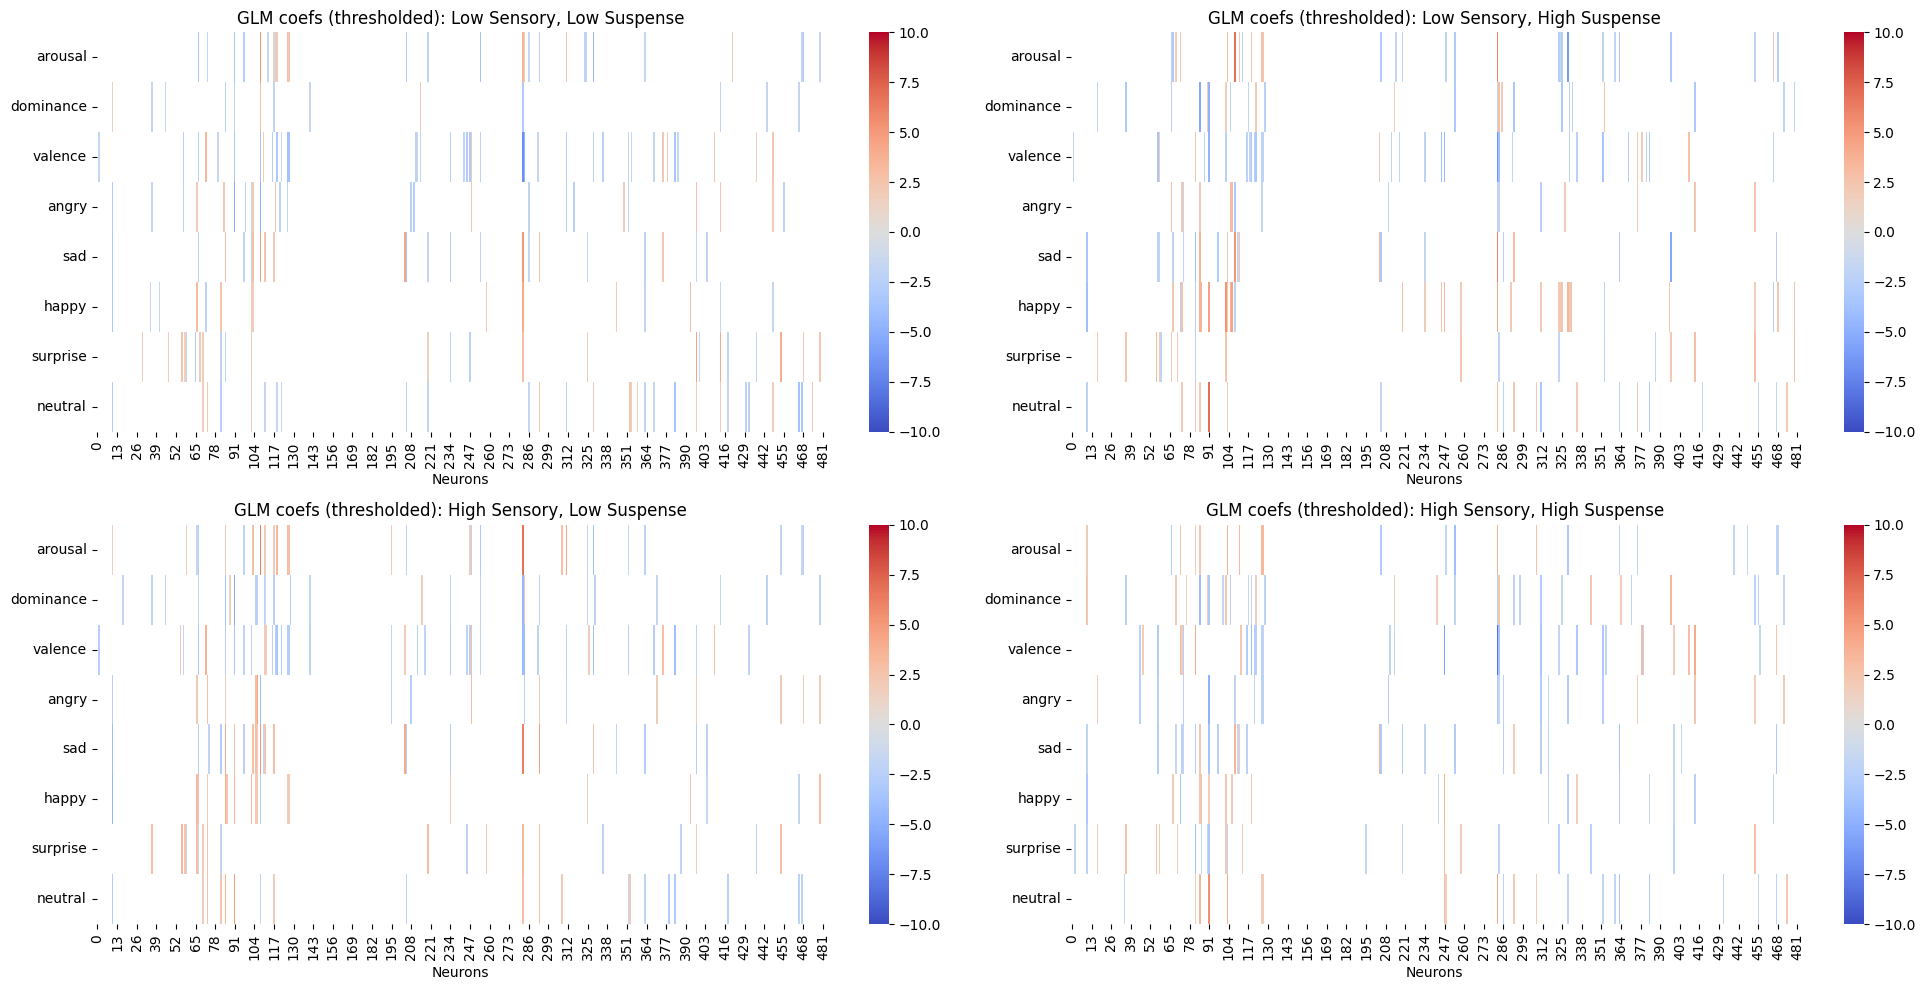

In [36]:
# plot
region = 'amygdala'

fig, axs = plt.subplots(2, 2, figsize=(20, 10))
axs, ax = axs.flatten(), 0
plt_rng = 10

for cond in range(4):

    if region == '': cond_T_by_N = T_by_N.copy() # full mtx
    else:            cond_T_by_N = get_region_mtx(df_FRs, region).copy() # region mtx

    # index condition times
    cond_T_by_N = cond_T_by_N[sen_sus_conds != cond, :].copy()
    cond_T_by_feats = T_by_feats[sen_sus_conds != cond, :].copy()

    glm_coefs = get_GLM(cond_T_by_feats, cond_T_by_N)
    
    mask = np.abs(glm_coefs) > np.percentile(np.abs(glm_coefs), 95)
    sns.heatmap(glm_coefs, mask=~mask, cmap='coolwarm', ax=axs[ax], cbar=True, vmax=plt_rng, vmin=-plt_rng)
    # sns.clustermap(glm_coefs, cmap='coolwarm', col_cluster=True, row_cluster=False)
    axs[ax].set(title=f'GLM coefs (thresholded): {cond_names[cond]}', xlabel='Neurons')
    axs[ax].set_yticklabels(df_audio.columns, rotation=0)
    ax += 1

plt.tight_layout()
plt.show()

### autocorr

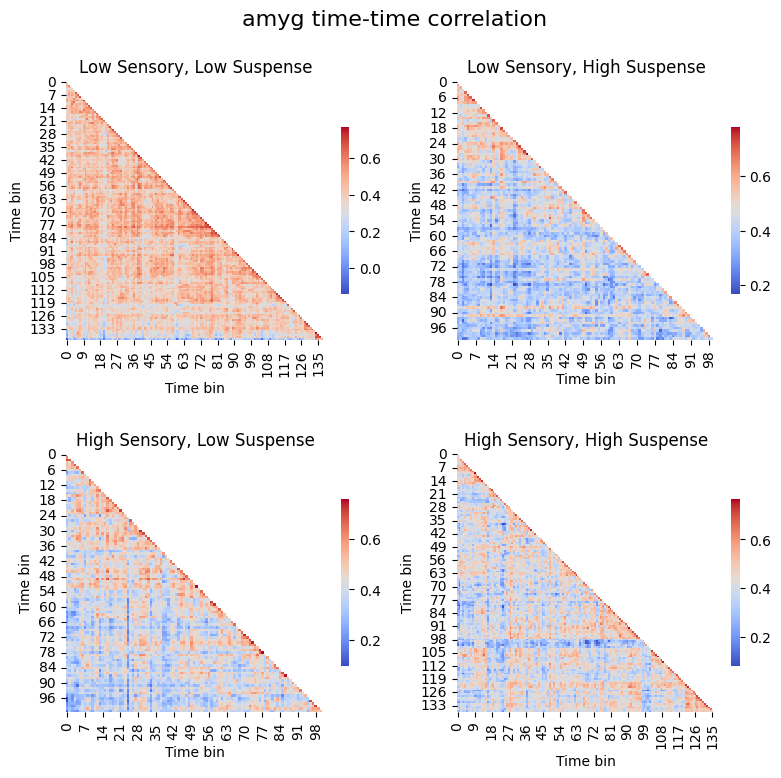

In [37]:
# plot
sen_sus_conds = get_conds(df_audio, avg_suspense)
fig, axs = plt.subplots(2, 2, figsize=(8, 8))
axs, ax = axs.flatten(), 0
plt_rng = 10
region = 'amyg'

for cond in range(4):

    if region == '': cond_T_by_N = T_by_N.copy() # full mtx
    else:            cond_T_by_N = get_region_mtx(df_FRs, region).copy() # region mtx

    # index condition times
    cond_T_by_N = cond_T_by_N[sen_sus_conds == cond, :].copy()

    tt_corr = np.corrcoef(cond_T_by_N)
    mask = np.triu(np.ones_like(tt_corr, dtype=bool))
    sns.heatmap(tt_corr, mask=mask, cmap='coolwarm', square=True, ax=axs[ax], cbar_kws={'shrink': 0.5})
    
    axs[ax].set(title=f'{cond_names[cond]}', xlabel='Time bin', ylabel='Time bin')
    ax += 1

if region != '': plt.suptitle(f'{region} time-time correlation', fontsize=16)
plt.tight_layout()
plt.show()

### avg FR

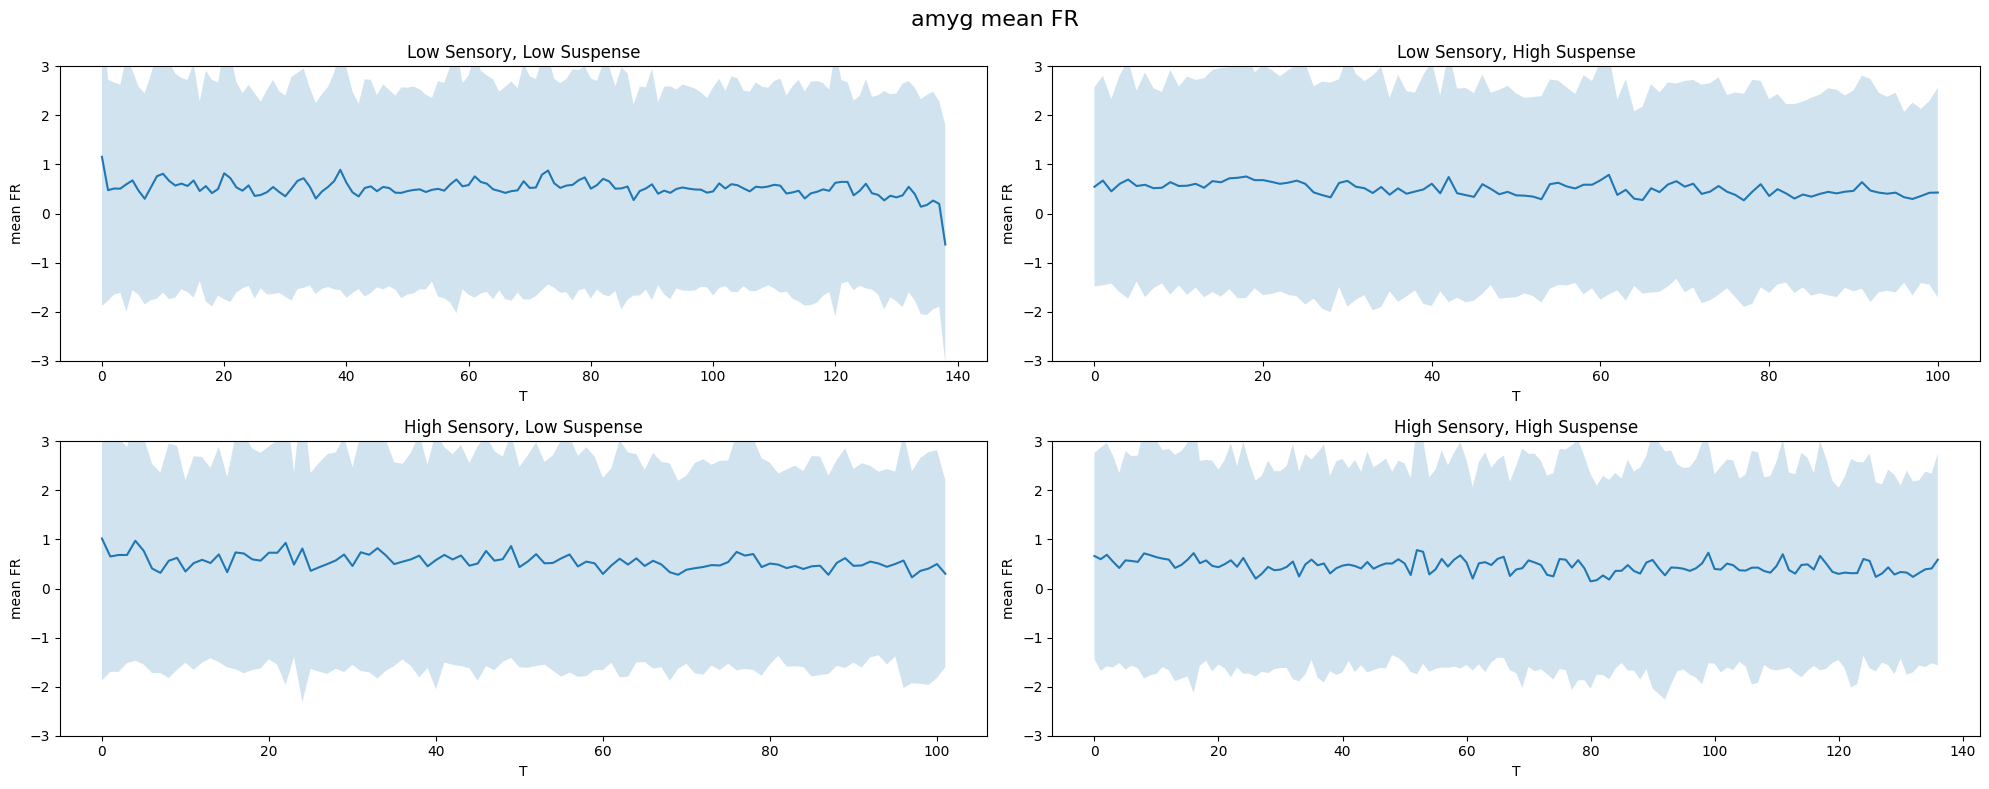

In [ ]:
# plot
sen_sus_conds = get_conds(df_audio, avg_suspense)
fig, axs = plt.subplots(2, 2, figsize=(20, 8))
axs, ax = axs.flatten(), 0
plt_rng = 3
region = 'amyg'

for cond in range(4):

    if region == '': cond_N_by_T = N_by_T.copy() # full mtx
    else:            cond_N_by_T = get_region_mtx(df_FRs, region).copy().T # region mtx

    # index condition times
    cond_N_by_T = cond_N_by_T[:, sen_sus_conds == cond].copy()

    mean_FR = cond_N_by_T.mean(axis=0)
    std_FR  = cond_N_by_T.std(axis=0)
    t = np.arange(len(mean_FR))

    axs[ax].plot(t, mean_FR)
    axs[ax].fill_between(t, mean_FR - std_FR, mean_FR + std_FR, alpha=0.2)

    axs[ax].set(title=f'{cond_names[cond]}', xlabel='T', ylabel='mean FR', ylim=(-plt_rng, plt_rng))
    ax += 1

plt.suptitle(f'{region} mean FR', fontsize=16)
plt.tight_layout()
plt.show()
